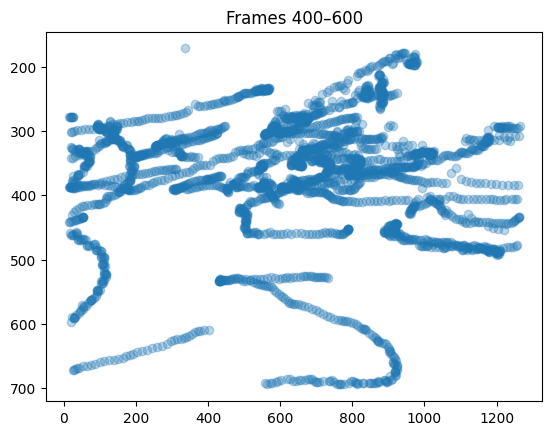

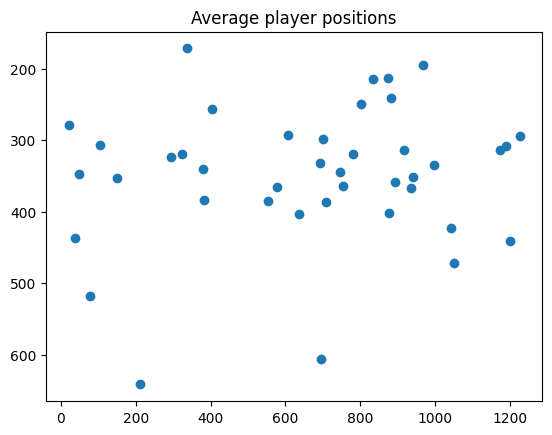

In [2]:
from pathlib import Path
from matplotlib import pyplot as plt
import pandas as pd

BASE = Path().resolve().parent  # goes up from notebooks
df = pd.read_csv(BASE / "outputs" / "best_segment_tracking_clip_0_1_clean.csv")

sample = df[(df["frame"] >= 400) & (df["frame"] <= 600)]

plt.scatter(sample["foot_x"], sample["foot_y"], alpha=0.3)
plt.gca().invert_yaxis()
plt.title("Frames 400–600")
plt.show()

player_positions = (
    sample.groupby("track_id")[["foot_x", "foot_y"]]
    .mean()
    .reset_index()
)

plt.scatter(player_positions["foot_x"], player_positions["foot_y"])
plt.gca().invert_yaxis()
plt.title("Average player positions")
plt.show()

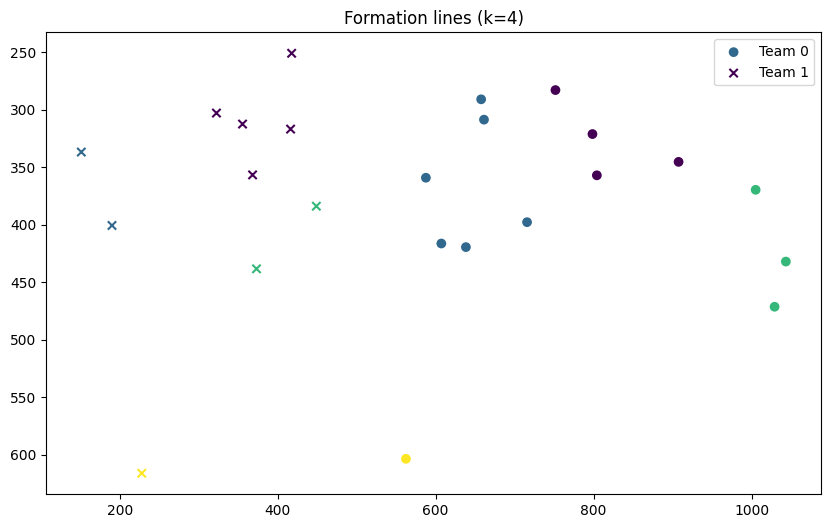

line
0    5
1    2
2    2
3    1
dtype: int64

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

clusterdf = pd.read_csv(BASE / "outputs" / "best_segment_team_clusters.csv")

team0 = clusterdf[clusterdf["team"] == 0].copy()
team1 = clusterdf[clusterdf["team"] == 1].copy()

def cluster_lines(team_df, k=3):
    X = team_df[["foot_x", "foot_y"]]
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    team_df["line"] = kmeans.fit_predict(X)
    return team_df

def sort_lines(team_df):
    line_order = team_df.groupby("line")["foot_y"].mean().sort_values().index
    mapping = {old: new for new, old in enumerate(line_order)}
    team_df["line"] = team_df["line"].map(mapping)
    return team_df

team0 = cluster_lines(team0, k=4)
team1 = cluster_lines(team1, k=4)
team0 = sort_lines(team0)
team1 = sort_lines(team1)

plt.figure(figsize=(10,6))

plt.scatter(team0["foot_x"], team0["foot_y"], c=team0["line"], marker='o', label='Team 0')
plt.scatter(team1["foot_x"], team1["foot_y"], c=team1["line"], marker='x', label='Team 1')

plt.gca().invert_yaxis()
plt.title("Formation lines (k=4)")
plt.legend()
plt.show()

team0.groupby("line").size()
team1.groupby("line").size()

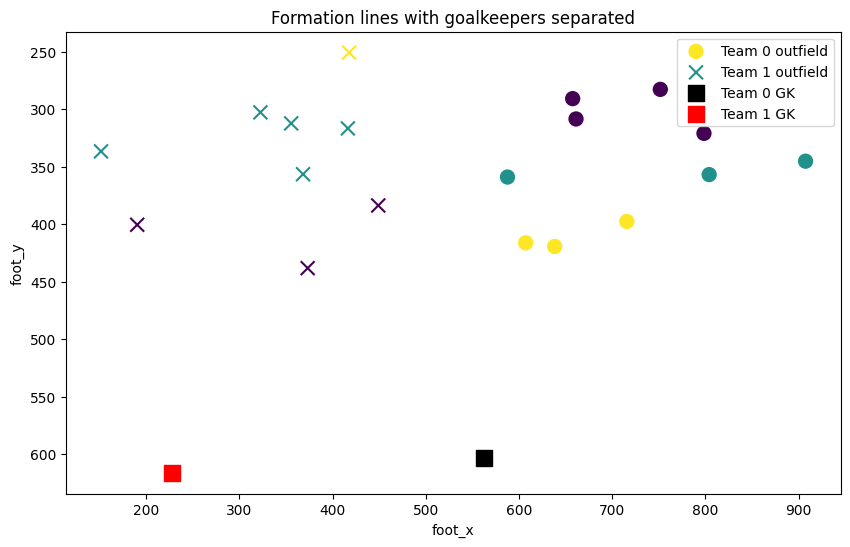

Team 0 outfield line counts:
line
0    4
1    3
2    3
dtype: int64
Team 0 goalkeeper count: 1

Team 1 outfield line counts:
line
0    3
1    5
2    1
dtype: int64
Team 1 goalkeeper count: 1


In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  

def remove_team_outliers(team_df, max_dist=150):
    team_df = team_df.copy()

    cx = team_df["foot_x"].median()
    cy = team_df["foot_y"].median()

    dist = np.sqrt(
        (team_df["foot_x"] - cx)**2 +
        (team_df["foot_y"] - cy)**2
    )

    team_df["dist"] = dist

    filtered = team_df[team_df["dist"] <= max_dist].copy()
    return filtered.drop(columns=["dist"])

clusterdf = pd.read_csv(BASE / "outputs" / "best_segment_team_clusters.csv")

team0 = clusterdf[clusterdf["team"] == 0].copy()
team1 = clusterdf[clusterdf["team"] == 1].copy()

def cluster_lines(team_df, k=3):
    team_df = team_df.copy()
    X = team_df[["foot_y"]]   # ONLY Y for formation depth
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    team_df["line"] = kmeans.fit_predict(X)
    return team_df

def sort_lines(team_df):
    team_df = team_df.copy()
    line_order = (
        team_df.groupby("line")["foot_y"]
        .mean()
        .sort_values()
        .index
    )
    mapping = {old: new for new, old in enumerate(line_order)}
    team_df["line"] = team_df["line"].map(mapping)
    return team_df

def reverse_lines(team_df):
    team_df = team_df.copy()
    max_line = team_df["line"].max()
    team_df["line"] = max_line - team_df["line"]
    return team_df

def split_goalkeeper(team_df):
    team_df = team_df.copy()
    gk_idx = team_df["foot_y"].idxmax()
    goalkeeper = team_df.loc[[gk_idx]].copy()
    outfield = team_df.drop(index=gk_idx).copy()
    return goalkeeper, outfield

gk0, team0_out = split_goalkeeper(team0)
gk1, team1_out = split_goalkeeper(team1)

team0_out = remove_team_outliers(team0_out, max_dist=250)
team1_out = remove_team_outliers(team1_out, max_dist=250)



team0_lines = sort_lines(cluster_lines(team0_out, k=3))
team1_lines = sort_lines(cluster_lines(team1_out, k=3))
team1_lines = reverse_lines(team1_lines)

gk0["line"] = -1
gk1["line"] = -1

team0_final = pd.concat([team0_lines, gk0], ignore_index=True)
team1_final = pd.concat([team1_lines, gk1], ignore_index=True)

plt.figure(figsize=(10, 6))

plt.scatter(
    team0_lines["foot_x"],
    team0_lines["foot_y"],
    c=team0_lines["line"],
    marker="o",
    s=100,
    label="Team 0 outfield"
)

plt.scatter(
    team1_lines["foot_x"],
    team1_lines["foot_y"],
    c=team1_lines["line"],
    marker="x",
    s=100,
    label="Team 1 outfield"
)

plt.scatter(
    gk0["foot_x"],
    gk0["foot_y"],
    c="black",
    marker="s",
    s=140,
    label="Team 0 GK"
)

plt.scatter(
    gk1["foot_x"],
    gk1["foot_y"],
    c="red",
    marker="s",
    s=140,
    label="Team 1 GK"
)

plt.gca().invert_yaxis()
plt.title("Formation lines with goalkeepers separated")
plt.xlabel("foot_x")
plt.ylabel("foot_y")
plt.legend()
plt.show()

print("Team 0 outfield line counts:")
print(team0_lines.groupby("line").size().sort_index())
print("Team 0 goalkeeper count:", len(gk0))

print("\nTeam 1 outfield line counts:")
print(team1_lines.groupby("line").size().sort_index())
print("Team 1 goalkeeper count:", len(gk1))